In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/amazon-sales-dataset/amazon_sales_dataset.csv


# 1️⃣ Import Libraries


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Optional: make plots look nicer
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

# 2️⃣ Load the Dataset


In [3]:
df = pd.read_csv("/kaggle/input/amazon-sales-dataset/amazon_sales_dataset.csv")

# Quick look at the data
df.head()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


# 3️⃣ Basic Info & Stats


In [4]:
print("Dataset Shape:", df.shape)
print("\nColumn Info:\n", df.info())
print("\nSummary Statistics:\n", df.describe())

Dataset Shape: (50000, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          50000 non-null  int64  
 1   order_date        50000 non-null  object 
 2   product_id        50000 non-null  int64  
 3   product_category  50000 non-null  object 
 4   price             50000 non-null  float64
 5   discount_percent  50000 non-null  int64  
 6   quantity_sold     50000 non-null  int64  
 7   customer_region   50000 non-null  object 
 8   payment_method    50000 non-null  object 
 9   rating            50000 non-null  float64
 10  review_count      50000 non-null  int64  
 11  discounted_price  50000 non-null  float64
 12  total_revenue     50000 non-null  float64
dtypes: float64(4), int64(5), object(4)
memory usage: 5.0+ MB

Column Info:
 None

Summary Statistics:
            order_id    product_id         price  discou

# 4️⃣ Data Cleaning Check


In [5]:
# Check for missing values
print(df.isnull().sum())

# Check for duplicates
print("Duplicates:", df.duplicated().sum())

order_id            0
order_date          0
product_id          0
product_category    0
price               0
discount_percent    0
quantity_sold       0
customer_region     0
payment_method      0
rating              0
review_count        0
discounted_price    0
total_revenue       0
dtype: int64
Duplicates: 0


# 5️⃣ Exploratory Data Analysis (EDA)


# 5a. Orders over time


In [6]:
orders_time = df.groupby('order_date')['order_id'].count().reset_index()
fig = px.line(orders_time, x='order_date', y='order_id',
              title='📈 Number of Orders Over Time',
              labels={'order_id': 'Number of Orders', 'order_date':'Order Date'})
fig.show()

# 5b. Revenue by Product Category


In [7]:
category_revenue = df.groupby('product_category')['total_revenue'].sum().sort_values(ascending=False).reset_index()
fig = px.bar(category_revenue, x='product_category', y='total_revenue', color='total_revenue',
             title='💰 Total Revenue by Product Category', text='total_revenue')
fig.show()

# 5c. Regional Sales Distribution


In [8]:
region_sales = df.groupby('customer_region')['total_revenue'].sum().reset_index()
fig = px.pie(region_sales, names='customer_region', values='total_revenue', 
             title='🌍 Revenue Distribution by Region')
fig.show()

# 5d. Discount vs Revenue Analysis


In [9]:
fig = px.scatter(df, x='discount_percent', y='total_revenue', 
                 color='product_category', 
                 title='💸 Discount vs Revenue by Product Category',
                 hover_data=['price', 'quantity_sold'])
fig.show()

# 5e. Ratings Distribution


In [10]:
fig = px.histogram(df, x='rating', nbins=20, color='product_category',
                   title='⭐ Customer Ratings Distribution')
fig.show()

# 5f. Heatmap of Correlations


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.



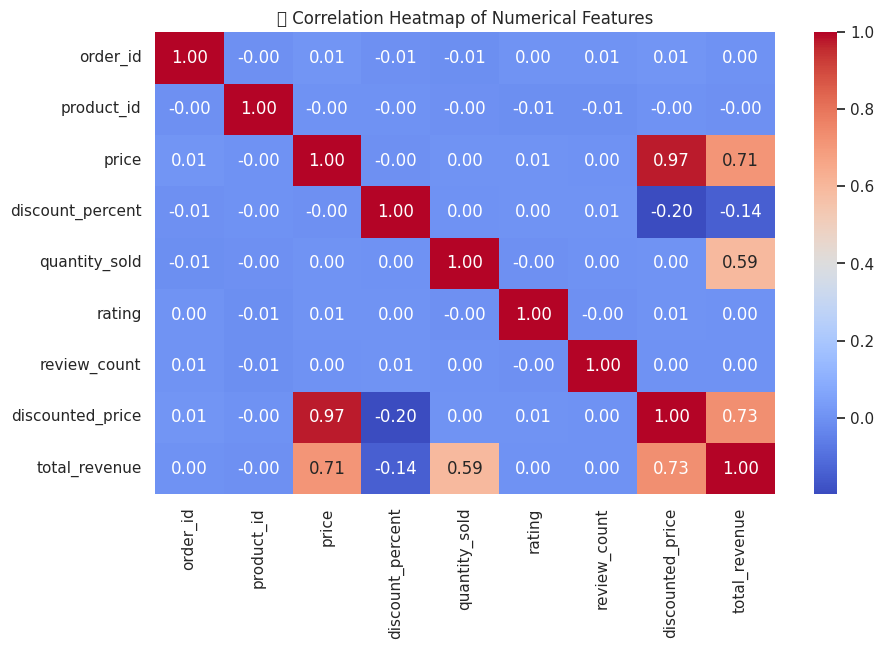

In [11]:
# Select numeric columns only
numeric_df = df.select_dtypes(include=np.number)

# Plot correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("🔗 Correlation Heatmap of Numerical Features")
plt.show()

# 6️⃣ Optional Advanced Analysis


In [12]:
# Top 10 products by revenue
top_products = df.groupby('product_id')['total_revenue'].sum().sort_values(ascending=False).head(10).reset_index()
fig = px.bar(top_products, x='product_id', y='total_revenue', 
             title='🏆 Top 10 Products by Revenue', text='total_revenue')
fig.show()